# Pachete necesare pentru folosirea acestui Notebook

Vom folosi [scipy](https://scipy.org/), [numpy](https://numpy.org/) și [matplotlib](https://matplotlib.org/).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import misc, ndimage
from scipy.fft import dctn, idctn

C:\Users\crist\AppData\Local\Temp\ipykernel_46896\1501482610.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc, ndimage


# Imaginea cu care lucrăm

Vom folosi o imagine din setul de date oferit implicit de către scipy.

In [ ]:
# X = misc.ascent()
# plt.imshow(X, cmap=plt.cm.gray)
# plt.show()


# NU MERGEEEEEEE ASA! deprecated....

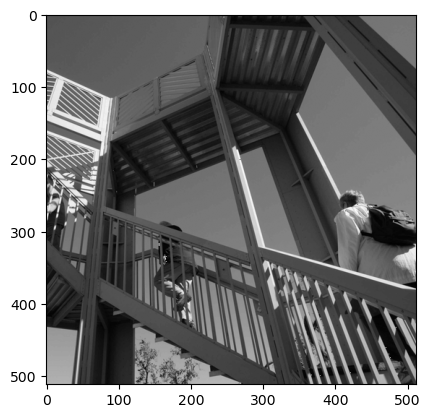

In [2]:
# conda install pooch in anaconda prompt

from scipy.datasets import ascent

X = ascent()
plt.imshow(X, cmap='gray')
plt.show()


# Transformata DCT a unei imagini

Transformata DCT se extinde la mai multe dimensiuni similar cu transformata DFT. Pentru un semnal bidimensional, precum o imagine, DCT-II devine:

$$
Y_{m_1,m_2} = \sum_{n_1=0}^{N_1-1}
              \sum_{n_2=0}^{N_2-1}
              x_{n_1,n_2}
              \cos\left[\frac{\pi}{N_1}m_1
                \left(n_1 + \frac12\right)\right]
              \cos\left[\frac{\pi}{N_2}m_2\left(n_2 + \frac12\right)\right]
$$

* unde $n_1$ și $n_2$ sunt pozițile pixelilor pe orizontală, respectiv, pe verticală
* bin-urile rezultate corespund pozițiilor pixelilor
* spectrul este în continuare simetric și par
* proprietățile transformatei DCT-II sunt respectate și în cazul celei 2D

În Python avem rutina `scipy.fft.dct` pentru 1D și `scipy.fft.dctn` pentru generalizarea la semnale $n$-dimensionale. Dimensiunea este determinată automat după forma semnalului; tipul DCT poate fi specificat prin atributul `type` (implicit II).

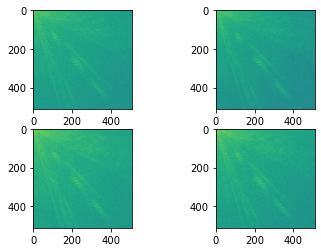

In [ ]:
Y1 = dctn(X, type=1)
Y2 = dctn(X, type=2)
Y3 = dctn(X, type=3)
Y4 = dctn(X, type=4)
freq_db_1 = 20*np.log10(abs(Y1))
freq_db_2 = 20*np.log10(abs(Y2))
freq_db_3 = 20*np.log10(abs(Y3))
freq_db_4 = 20*np.log10(abs(Y4))

plt.subplot(221).imshow(freq_db_1)
plt.subplot(222).imshow(freq_db_2)
plt.subplot(223).imshow(freq_db_3)
plt.subplot(224).imshow(freq_db_4)
plt.show()

# Convertesc in dB ca sa fac vizibila distributia frecventelor.
# abs pt ca DCT produce valori pozitive si negative, iar logaritmul cere valori pozitive.

# Compactarea energiei. Compresie.

Putem profita de proprietatea compresiei energiei prin anularea frecvențelor DCT începând cu *bin*-ul `k` după care aplicăm transformata DCT inversă (similar cu tema anterioară):

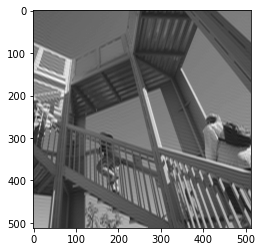

In [6]:
k = 120

Y_ziped = Y2.copy()
Y_ziped[k:] = 0
X_ziped = idctn(Y_ziped)

plt.imshow(X_ziped, cmap=plt.cm.gray)
plt.show()

# JPEG

Algoritmul de compresie JPEG are patru etape:

1. transformarea imaginii din pixeli RGB în Y'CbCr
2. aplicarea 2D-DCT pe blocuri disincte de 8x8 pixeli din imagine
3. cuantizarea în frecvență cu $Q$ dat de standardul JPEG
4. compresia rezultatului cu coduri Huffman

Unde matricea JPEG de cuantizare $Q$ este:
$$
Q =
\begin{bmatrix}
16 & 11 & 10 & 16 & 24 & 40 & 51 & 61 & \\
12 & 12 & 14 & 19 & 26 & 28 & 60 & 55 & \\
14 & 13 & 16 & 24 & 40 & 57 & 69 & 56 & \\
14 & 17 & 22 & 29 & 51 & 87 & 80 & 62 & \\
18 & 22 & 37 & 56 & 68 & 109 & 103 & 77 & \\
24 & 35 & 55 & 64 & 81 & 104 & 113 & 92 & \\
49 & 64 & 78 & 87 & 103 & 121 & 120 & 101\\
72 & 92 & 95 & 98 & 112 & 100 & 103 & 99\\
\end{bmatrix}
$$

Imaginea noastră de test este monocromă, deci nu necesită pasul 1, dar putem efectua o operație de *down-sampling* în preprocesare precum am prezentat la curs.

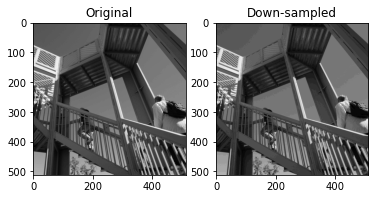

In [7]:
Q_down = 10

X_jpeg = X.copy()
X_jpeg = Q_down*np.round(X_jpeg/Q_down);

plt.subplot(121).imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(X_jpeg, cmap=plt.cm.gray)
plt.title('Down-sampled')
plt.show()

Pentru fiecare bloc de $8\times 8$ aplică DCT și cuantizare.

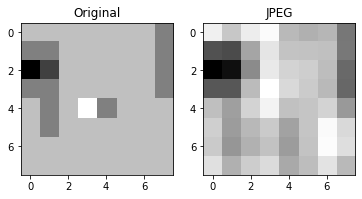

Componente în frecvență:64
Componente în frecvență după cuantizare: 14


In [9]:
Q_jpeg = [[16, 11, 10, 16, 24, 40, 51, 61],
          [12, 12, 14, 19, 26, 28, 60, 55],
          [14, 13, 16, 24, 40, 57, 69, 56],
          [14, 17, 22, 29, 51, 87, 80, 62],
          [18, 22, 37, 56, 68, 109, 103, 77],
          [24, 35, 55, 64, 81, 104, 113, 92],
          [49, 64, 78, 87, 103, 121, 120, 101],
          [72, 92, 95, 98, 112, 100, 103, 99]]

# Encoding
x = X[:8, :8]
y = dctn(x)
y_jpeg = Q_jpeg*np.round(y/Q_jpeg)

# Decoding
x_jpeg = idctn(y_jpeg)

# Results
y_nnz = np.count_nonzero(y)
y_jpeg_nnz = np.count_nonzero(y_jpeg)

plt.subplot(121).imshow(x, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(x_jpeg, cmap=plt.cm.gray)
plt.title('JPEG')
plt.show()

print('Componente în frecvență:' + str(y_nnz) + 
      '\nComponente în frecvență după cuantizare: ' + str(y_jpeg_nnz))

# Sarcini

1. [6p] Completați algoritmul JPEG incluzând toate blocurile din imagine.

2. [4p] Extindeți la imagini color (incluzând transformarea din RGB în Y'CbCr).

3. [6p] Extindeți algoritmul pentru compresia imaginii până la un prag MSE impus de utilizator.

4. [4p] Extindeți algoritmul pentru compresie video. Demonstrați pe un clip scurt din care luați fiecare cadru și îl tratați ca pe o imagine.

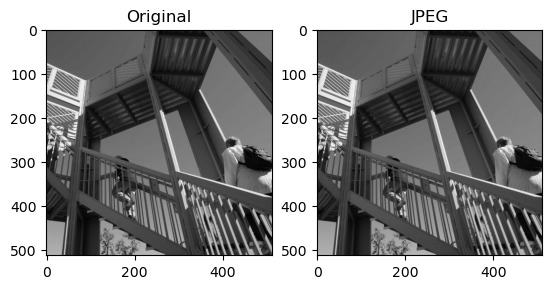

Componente în frecvență:250424
Componente în frecvență după cuantizare: 125064


In [4]:
# Taskul 1
# completare alg. JPEG incluzand toate blocurile din imagine

X = ascent()

Q_jpeg = [[16, 11, 10, 16, 24, 40, 51, 61],
          [12, 12, 14, 19, 26, 28, 60, 55],
          [14, 13, 16, 24, 40, 57, 69, 56],
          [14, 17, 22, 29, 51, 87, 80, 62],
          [18, 22, 37, 56, 68, 109, 103, 77],
          [24, 35, 55, 64, 81, 104, 113, 92],
          [49, 64, 78, 87, 103, 121, 120, 101],
          [72, 92, 95, 98, 112, 100, 103, 99]]

x = X.copy()

#Padd-uiesc imaginea ca sa aiba numar intreg de blocuri 8x8 (adaug zerouri)
nr_rows, nr_cols = x.shape
new_rows = nr_rows + (8 - nr_rows % 8)% 8
new_cols = nr_cols + (8 - nr_cols % 8)% 8
x_padded = np.zeros((new_rows, new_cols))
x_padded[:nr_rows, :nr_cols] = x


#DCT pe fiecare bloc de 8 pe 8 + cuantizare + IDCT pentru a obtine imaginea comprimata
componente_in_frecventa = 0
componente_in_frecventa_dupa_cuantizare = 0

h, w = x_padded.shape
X = np.zeros((h, w)) #in X stochez rezultatul aplicarii DCT pe imagine
for i in range(0, h, 8):
    for j in range(0, w, 8):
        block = x_padded[i:i+8, j:j+8]
        DCT_bloc_curent = dctn(block, type=2) #DCT a blocului curent
        
        componente_in_frecventa = componente_in_frecventa + np.count_nonzero(DCT_bloc_curent)
        
        DCT_cuantizat = Q_jpeg * np.round(DCT_bloc_curent / Q_jpeg) #cuantizare
        X[i:i+8, j:j+8] = DCT_cuantizat #salvez reprezentarea in frecventa a blocului in X

componente_in_frecventa_dupa_cuantizare = np.count_nonzero(X)

x_jpeg = np.zeros((h, w)) #in x_jpeg stochez imaginea comprimata
for i in range(0, h, 8):
    for j in range(0, w, 8):
        block = X[i:i+8, j:j+8]
        IDCT_bloc_curent = idctn(block, type=2) #IDCT a blocului curent
        x_jpeg[i:i+8, j:j+8] = IDCT_bloc_curent #salvez blocul reconstruit in x_jpeg

#elimin padding-ul adaugat initial pt a putea forma blocuri 8x8
x_jpeg = x_jpeg[:nr_rows, :nr_cols]


plt.subplot(121).imshow(x, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(x_jpeg, cmap=plt.cm.gray)
plt.title('JPEG')
plt.show()

print('Componente în frecvență:' + str(componente_in_frecventa) +
        '\nComponente în frecvență după cuantizare: ' + str(componente_in_frecventa_dupa_cuantizare))



In [ ]:
# Task 2
# Extind alg. la imagini color (conversie RGB -> YCbCr)

Q_luma = np.array([ #matricea de cuantizare pentru canalul Y (brightness)
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float64)

Q_chroma = np.array([ # matricea de cuantizare pentru canalele Cb si Cr (color)
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
], dtype=np.float64) #! cuantizare si mai puternica pentru canalele de culoare, pt ca ochiul uman e mai putin sensibil la detalii de culoare


def image_from_rgb_to_ycbcr(img_rgb):
    R = img_rgb[:, :, 0]  #extrag separat pentru fiecare canal de culoare
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]
    
    Y  =  0.299*R + 0.587*G + 0.114*B
    Cb = -0.168736*R - 0.331264*G + 0.5*B + 128.0    #Cb ∝ (B−Y)   // cat albastru am in plus fata de cat de luminos e pixelul
                                                    # Cb = aprox. = 0.564(B−Y)+128
    Cr =  0.5*R - 0.418688*G - 0.081312*B + 128.0    #Cr ∝ (R−Y)   //      rosu
                                                    # Cr ≈ aprox. = 0.713(R−Y)+128
                                                    
    # Rolul lui +128: 
    # - valorile din Cb si Cr pot fi intre -128 si 128. 
    # - adunand 128, le centrez in 128 si ma asigur ca toate sunt pozitive => valori posibile intre 0 si 255
    # - daca nu s-ar aduna acest offset, JPEG-ul ar trebui sa stocheze numere cu semn => ineficient
    # - in intervalul 0 - 255, in care lucrez acum:
        # 128 = nu exista nicio nuanta de albastru sau rosu dominanta (zona neutra/gri dpdv culoare)
        # <128 = absenta sau complementara culorii respective (nuante de galben sau verde)
        # > 128 = prezenta culorii respective = mai mult albastru sau mai mult rosu
        
    return np.clip(np.stack([Y, Cb, Cr], axis=-1), 0, 255).astype(np.uint8)

def image_from_ycbcr_to_rgb(img_ycbcr):
    Y  = img_ycbcr[:,:,0]
    Cb = img_ycbcr[:,:,1] - 128.0
    Cr = img_ycbcr[:,:,2] - 128.0
    R = Y + 1.402*Cr
    G = Y - 0.344136*Cb - 0.714136*Cr
    B = Y + 1.772*Cb
    rgb = np.stack([R, G, B], axis=-1)
    return np.clip(rgb, 0, 255).astype(np.uint8) #fortez valorile pixelilor sa fie intre 0 si 255. ORice val <0 devine 0, iar orice val. >255 devine 255

def compress_image_to_jpeg(x, Q_jpeg, #x = imagine cu un singur canal
                        verbose = True, #verbose = daca sa se afiseze plot original vs jpeg + nr_frecvente_initial vs nr_frecvente_dupa_quantizare
                        cmap = plt.cm.gray): #cmapul folosit pentru plot (daca verbose = True). default = grayscale. Va putea fi RdYlBu_r/RdYlGn_r in functia mare care apeleaza compresia jpeg pe canale (Y/CB/Cr)
                                            #setez verbose = True si cmap = None daca vreau sa afisez doar variatia numarului de frecvente dupa cuantizare si nu si imaginea comprimata

    #Padd-uiesc imaginea ca sa aiba numar intreg de blocuri 8x8 (adaug zerouri)
    nr_rows, nr_cols = x.shape
    new_rows = nr_rows + (8 - nr_rows % 8)
    new_cols = nr_cols + (8 - nr_cols % 8)
    x_padded = np.zeros((new_rows, new_cols))
    x_padded[:nr_rows, :nr_cols] = x


    #DCT pe fiecare bloc de 8 pe 8 + cuantizare + IDCT pentru a obtine imaginea comprimata
    componente_in_frecventa = 0
    componente_in_frecventa_dupa_cuantizare = 0

    h, w = x_padded.shape
    X = np.zeros((h, w)) #in X stochez rezultatul aplicarii DCT pe imagine
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = x_padded[i:i+8, j:j+8]
            DCT_bloc_curent = dctn(block, type=2) #DCT a blocului curent
            
            componente_in_frecventa = componente_in_frecventa + np.count_nonzero(DCT_bloc_curent)
            
            DCT_cuantizat = Q_jpeg * np.round(DCT_bloc_curent / Q_jpeg) #cuantizare
            X[i:i+8, j:j+8] = DCT_cuantizat #salvez reprezentarea in frecventa a blocului in X

    componente_in_frecventa_dupa_cuantizare = np.count_nonzero(X)

    x_jpeg = np.zeros((h, w)) #in x_jpeg stochez imaginea comprimata
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = X[i:i+8, j:j+8]
            IDCT_bloc_curent = idctn(block, type=2) #IDCT a blocului curent
            x_jpeg[i:i+8, j:j+8] = IDCT_bloc_curent #salvez blocul reconstruit in x_jpeg

    #elimin padding-ul adaugat initial pt a putea forma blocuri 8x8
    x_jpeg = x_jpeg[:nr_rows, :nr_cols]

    if verbose:
        if cmap != None:
            plt.figure(figsize=(14,5))
            plt.subplot(121).imshow(x, cmap=cmap)
            plt.title('Original')
            plt.axis("off")
            plt.subplot(122).imshow(x_jpeg, cmap=cmap)
            plt.title('JPEG')
            plt.axis("off")
            plt.show()

        print('Componente în frecvență:' + str(componente_in_frecventa) +
                '\nComponente în frecvență după cuantizare: ' + str(componente_in_frecventa_dupa_cuantizare))

    return x_jpeg


#Functie care ma ajuta sa plotez mai accurate canalele Cb, Cr (mai accurate decat RdYlBu_r/RdYlGn_r):
def vizualizare_canale_cb_cr_idividual(canal2d, cb_or_cr): #cb_or_cr imi spune contributia carui canal vreau sa o vizualizez.
                                                            #primeste ca argument acel canal (matrice 2d) extras din imagine + numele canalului trimis ca argument (cb sau cr)
                                                            #celelalte doua canale sunt neutre
    h, w = canal2d.shape
    neutru = np.full((h, w), 128, dtype=np.uint8)
    
    if cb_or_cr == "cb":
        
        # Y=128, Cb=canal_primit, Cr=128
        img_ycbcr_in_care_doar_Cb_face_diferenta = np.stack([neutru, canal2d, neutru], axis=-1)
        return image_from_ycbcr_to_rgb(img_ycbcr_in_care_doar_Cb_face_diferenta)
    
    else: #cr
        # Y=128, Cb=128, Cr=canal_primit
        img_ycbcr_in_care_doar_Cr_face_diferenta = np.stack([neutru, neutru, canal2d], axis=-1)
        return image_from_ycbcr_to_rgb(img_ycbcr_in_care_doar_Cr_face_diferenta)



def compress_rgb_image_to_jpeg(img_rgb, Q_jpeg = Q_luma, Q_chroma=Q_chroma, verbose = True):
    img_ycbcr = image_from_rgb_to_ycbcr(img_rgb)
    Y  = img_ycbcr[:, :, 0]
    Cb = img_ycbcr[:, :, 1]
    Cr = img_ycbcr[:, :, 2]

    if verbose:
        print("\n")
        print("Canalul Y")
    Y_jpeg = compress_image_to_jpeg(Y, Q_jpeg, verbose=verbose) #cmap e default grayscale (ok pentru Y)
    if verbose:
        print("-------------------------------------------------------------------------------------------")
    
    if verbose:
        print("\n")
        print("Canalul Cb")
    Cb_jpeg = compress_image_to_jpeg(Cb, Q_chroma, verbose=verbose, cmap = None) # "RdYlBu_r")
    img_cb_rgb_jpeg = vizualizare_canale_cb_cr_idividual(Cb_jpeg, "cb")
    img_cb_rgb_original = vizualizare_canale_cb_cr_idividual(img_ycbcr[:,:,1], "cb")
    
    if verbose:
        plt.figure(figsize=(14,5))
        plt.subplot(121).imshow(img_cb_rgb_original)
        plt.title('Original - contributia canalului Cb')
        plt.axis("off")
        plt.subplot(122).imshow(img_cb_rgb_jpeg)
        plt.title('JPEG - contributia canalului Cb')
        plt.axis("off")
        plt.show()
        print("-------------------------------------------------------------------------------------------")

    if verbose:
        print("\n")
        print("Canalul Cr")
    Cr_jpeg = compress_image_to_jpeg(Cr, Q_chroma, verbose=verbose, cmap = None) #"RdYlGn_r")
    img_cr_rgb_jpeg = vizualizare_canale_cb_cr_idividual(Cr_jpeg, "cr")
    img_cr_rgb_original = vizualizare_canale_cb_cr_idividual(img_ycbcr[:,:,2], "cr")
        
    if verbose:
        plt.figure(figsize=(14,5))
        plt.subplot(121).imshow(img_cr_rgb_original)
        plt.title('Original - contributia canalului Cr')
        plt.axis("off")
        plt.subplot(122).imshow(img_cr_rgb_jpeg)
        plt.title('JPEG - contributia canalului Cr')
        plt.axis("off")
        plt.show()
    
    img_ycbcr_jpeg = np.stack([Y_jpeg, Cb_jpeg, Cr_jpeg], axis=-1)
    img_rgb_jpeg = image_from_ycbcr_to_rgb(img_ycbcr_jpeg)

    return img_rgb_jpeg





Canalul Y


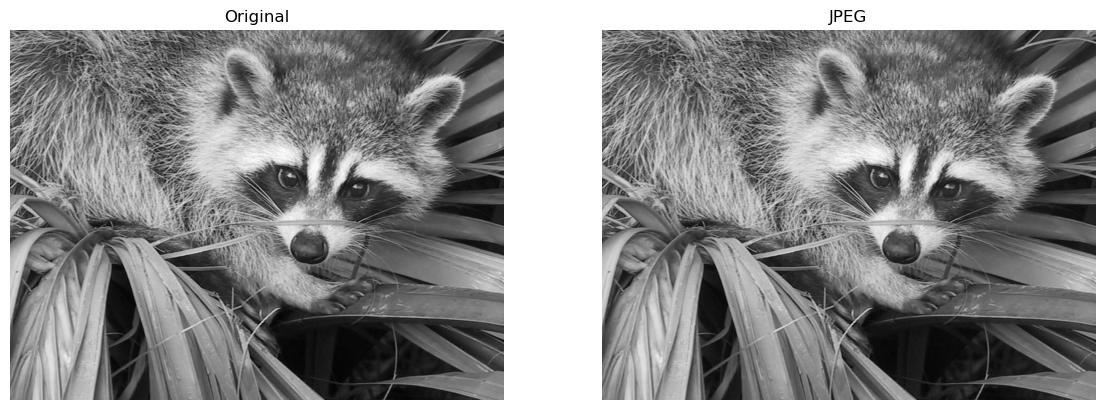

Componente în frecvență:774663
Componente în frecvență după cuantizare: 214513
-------------------------------------------------------------------------------------------


Canalul Cb
Componente în frecvență:596047
Componente în frecvență după cuantizare: 66882


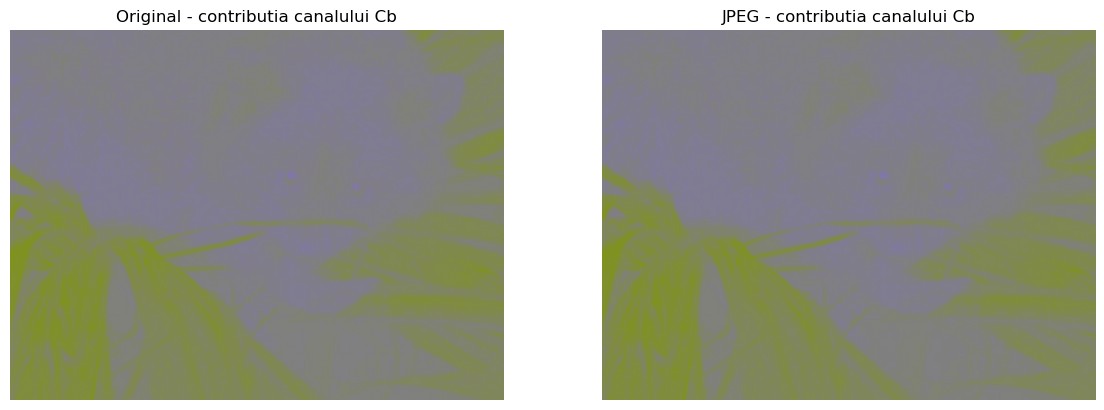

-------------------------------------------------------------------------------------------


Canalul Cr
Componente în frecvență:589023
Componente în frecvență după cuantizare: 60423


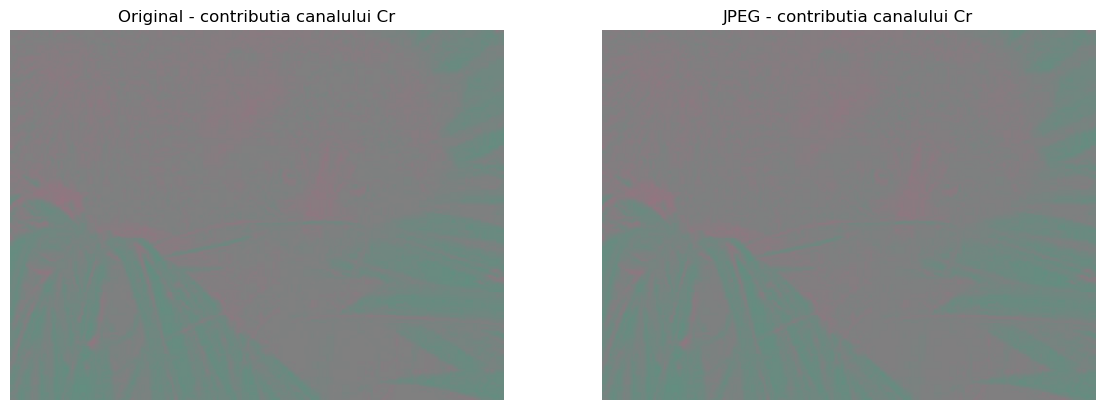

-------------------------------------------------------------------------------------------
Overall


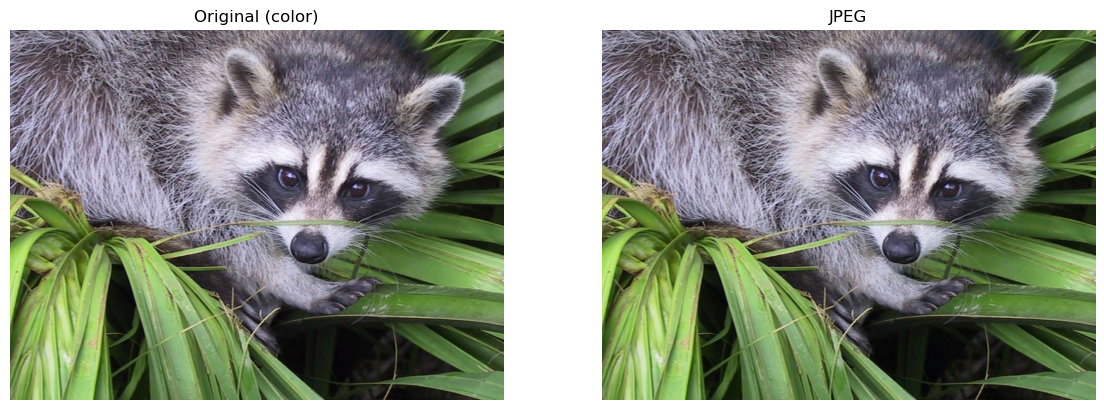

In [6]:
from scipy.datasets import face
img_color_test = face()

img_color_jpeg = compress_rgb_image_to_jpeg(img_color_test, verbose = True)

print("-------------------------------------------------------------------------------------------")
print("Overall")
plt.figure(figsize=(14,5))
plt.subplot(1,2,1); plt.imshow(img_color_test); plt.title("Original (color)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_color_jpeg); plt.title("JPEG"); plt.axis("off")
plt.show()

Prag MSE:  50
1. k=25.005 MSE=21.735714382595486
2. k=37.5025 MSE=34.65098232693143
3. k=43.75125 MSE=41.20129606458876
4. k=46.875625 MSE=44.92730161878798
5. k=48.4378125 MSE=47.4955931769477
6. k=49.21890625 MSE=48.13772879706489
7. k=49.609453125 MSE=48.75288772583008
8. k=49.8047265625 MSE=49.09343126085069
9. k=49.902363281250004 MSE=49.29575686984592
10. k=49.951181640625 MSE=49.43877495659722
11. k=49.975590820312505 MSE=49.47459454006619
12. k=49.98779541015625 MSE=49.488416035970054
13. k=49.993897705078126 MSE=49.519674936930336
BEST k: 49.993897705078126

BEST MSE: 49.519674936930336


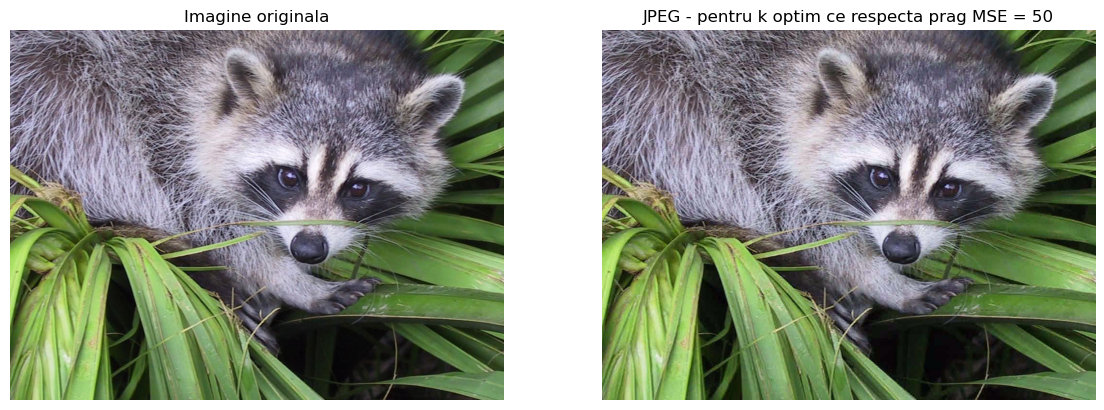

In [8]:
#Taskul 3
#Extindeți algoritmul pentru compresia imaginii până la un prag MSE impus de utilizator.


# Caut acel numar k care inmultit cu matricea de cuantizare Q
# produce cea mai buna compresie a imaginii, dar cu pierdere de informatie 
# nu mai mare decat pragul MSE impus de user.

# cu cat k e mai mare => k*Q mai mare => quantizare mai dura => compresie mare => MSE mare
# cu cat k e mai mic => k*Q mai mic -> quantizare mai relaxata => compresie putina => MSE mic

# Deci MSE creste cand k creste si scade cand k scade.
# => k care genereaza compresia cea mai puternica, dar care nu depaseste MSE impus poate fi determinat cu ajutorul CAUTARII BINARE.


def mse(imgA, imgB):
    return np.mean((imgA.astype(np.float64) - imgB.astype(np.float64)) ** 2)

def find_k_using_binary_search_to_satisfy_MSE(img_rgb, prag_MSE, Q_luma=Q_luma, Q_chroma = Q_chroma):
    print("Prag MSE: ", prag_MSE)
    
    lower_bound_k = 0.01 #nu cuantizez aproape deloc
    upper_bound_k = 50 #cuantizare mult mai agresiva
    
    best_k = None
    best_MSE = None
    img_jpeg_produced_by_the_best_k = None
    
    nr_max_iteratii = 50
    nr_iteratii = 0
    
    while lower_bound_k < upper_bound_k and nr_iteratii < nr_max_iteratii:
        nr_iteratii+=1
        k_mid = (lower_bound_k + upper_bound_k)/2
        
        print(f"{nr_iteratii}. k={k_mid}", end = '')
        
        #comprim imaginea cu k_mid ca factor de scalare pt Q:
        Q_luma_curent = k_mid*Q_luma
        Q_chroma_curent = k_mid*Q_chroma
        
        img_jpeg = compress_rgb_image_to_jpeg(img_rgb, Q_luma_curent, Q_chroma_curent, verbose=False)
        
        MSE = mse(img_rgb, img_jpeg)
        print(f" MSE={MSE}", end = '')
        
        if MSE < prag_MSE and prag_MSE - MSE < 0.5: #toleranta
            best_k = k_mid
            best_MSE = MSE
            img_jpeg_produced_by_the_best_k = img_jpeg.copy()
            break
        
        if MSE > prag_MSE: #eroarea e prea mare => trebuie sa comprim mai putin => k scade!
            upper_bound_k = k_mid
        else: #eroarea e mica => pot comprima mai mult => incerc sa il cresc pe k!
            lower_bound_k = k_mid
            best_MSE = MSE
            best_k = k_mid
            img_jpeg_produced_by_the_best_k = img_jpeg.copy()
            
        print()
            
    print(f"\nBEST k: {best_k}")
    print(f"\nBEST MSE: {best_MSE}")
    
    plt.figure(figsize=(14,5))
    plt.subplot(121).imshow(img_rgb)
    plt.title('Imagine originala')
    plt.axis("off")
    plt.subplot(122).imshow(img_jpeg_produced_by_the_best_k)
    plt.title(f'JPEG - pentru k optim ce respecta prag MSE = {prag_MSE}')
    plt.axis("off")
    plt.show()
            
img_color_test = face()
find_k_using_binary_search_to_satisfy_MSE(img_color_test, 50)

In [9]:
# Taskul 4
# Extindeți algoritmul pentru compresie video. Demonstrați pe un clip scurt din care luați fiecare cadru și îl tratați ca pe o imagine.

import cv2
import os

def compress_video_frames_to_jpeg(video_path, output_path, Q_luma, Q_chroma):
    cap = cv2.VideoCapture(video_path) # deschid videoclipul
    
    fps = cap.get(cv2.CAP_PROP_FPS) # ii memorez carcateristicile
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Pentru videoclipul dat: ")
    print(f"- frame w/h: {width}/{height}")
    print(f"- FPS: {fps}")
    print(f"- Total frames: {total_frames}")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # definesc un writer pt video-ul comprimat
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) #pt ca videoul e implicit citit in BGR, convertesc la RGB
        frame_compressed_jpeg_rgb = compress_rgb_image_to_jpeg(frame_rgb, Q_luma, Q_chroma, verbose=False) # pt fiecare frame -> jpeg
        frame_final = cv2.cvtColor(frame_compressed_jpeg_rgb, cv2.COLOR_RGB2BGR) # si salvez frame-ul comprimat ca BGR
        
        out.write(frame_final)
        
        frame_idx += 1
        print(f"Procesat frame {frame_idx}")

    cap.release() #eliberare resurse
    out.release()

compress_video_frames_to_jpeg('budapesta.mp4', 'budapesta_compressed_to_jpegs.mp4', Q_luma, Q_chroma)

Pentru videoclipul dat: 
- frame w/h: 512/480
- FPS: 30.0
- Total frames: 50
Procesat frame 1
Procesat frame 2
Procesat frame 3
Procesat frame 4
Procesat frame 5
Procesat frame 6
Procesat frame 7
Procesat frame 8
Procesat frame 9
Procesat frame 10
Procesat frame 11
Procesat frame 12
Procesat frame 13
Procesat frame 14
Procesat frame 15
Procesat frame 16
Procesat frame 17
Procesat frame 18
Procesat frame 19
Procesat frame 20
Procesat frame 21
Procesat frame 22
Procesat frame 23
Procesat frame 24
Procesat frame 25
Procesat frame 26
Procesat frame 27
Procesat frame 28
Procesat frame 29
Procesat frame 30
Procesat frame 31
Procesat frame 32
Procesat frame 33
Procesat frame 34
Procesat frame 35
Procesat frame 36
Procesat frame 37
Procesat frame 38
Procesat frame 39
Procesat frame 40
Procesat frame 41
Procesat frame 42
Procesat frame 43
Procesat frame 44
Procesat frame 45
Procesat frame 46
Procesat frame 47
Procesat frame 48
Procesat frame 49
Procesat frame 50


# COMPRESIE REALA JPEG (incluzand memorarea bloc pe diagonale + Huffman)

# (nu doar quantizare, ca mai sus)

In [13]:
# auxiliare pentru salvare imag. in format comprimat (parcurgere valori bloc pe diagonale secundare + Huffman)

import heapq

def get_zigzag_indices(): #parcurgere bloc 8 x 8 pe diagonale pentru a obtine siruri lungi de 0 la final
    indices = [(i, j) for i in range(8) for j in range(8)]
    # Ordonare pe diagonale: suma i+j, apoi alternare
    indices.sort(key=lambda x: (x[0] + x[1], x[1] if (x[0] + x[1]) % 2 == 0 else x[0])) 
                    # toti pixelii de pe aceeasi D_sec au aceeasi suma a indicilor
                    # zig zag: daca suma e para => sortez dupa x[1] (dupa coloana) => pe diagonala aia merg de jos in sus
                    #               altfel => sortez dupa x[0], adica parcurg de sus in jos
    return indices

ZIGZAG_ORDER = get_zigzag_indices()

def block_to_zigzag(block): #returneaza lista valorilor din bloc puse in lista in ordinea in care au fost parcurse in zig zag
    return [block[i, j] for i, j in ZIGZAG_ORDER]

def zigzag_to_block(vector):
    block = np.zeros((8, 8))
    for val, (i, j) in zip(vector, ZIGZAG_ORDER):
        block[i, j] = val
    return block


class HuffmanNode:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = self.right = None
    def __lt__(self, other): return self.freq < other.freq

def huffman_encode(data):

    freqs = {}
    for val in data: 
        freqs[val] = freqs.get(val, 0) + 1
    
    heap = [HuffmanNode(c, f) for c, f in freqs.items()] # arborele
    heapq.heapify(heap)
    while len(heap) > 1:
        n1 = heapq.heappop(heap)
        n2 = heapq.heappop(heap)
        
        merged = HuffmanNode(None, n1.freq + n2.freq)
        
        merged.left = n1
        merged.right = n2
        
        heapq.heappush(heap, merged)
        
    # generare coduri:
    root = heap[0]
    codes = {}
    
    def build_codes(node, current_code):
        
        if not node: 
            return
        if node.char is not None: 
            codes[node.char] = current_code
            
        build_codes(node.left, current_code + "0")
        build_codes(node.right, current_code + "1")
        
    build_codes(root, "")
    
    bit_string = "".join([codes[val] for val in data])
    return bit_string, root

def huffman_decode(bit_string, root):
    decoded_data = []
    current_node = root
    
    for bit in bit_string:
        if bit == '0':
            current_node = current_node.left
        else:
            current_node = current_node.right
            
        if current_node.char is not None:
            decoded_data.append(current_node.char)
            current_node = root
            
    return decoded_data



Dimensiune original (fara niciun fel de compresie): 2304.00 KB
Dimensiune cu JPEG si Huffman: 377.63 KB
De cate ori mai eficient dpdv memorie: 6.10 ori


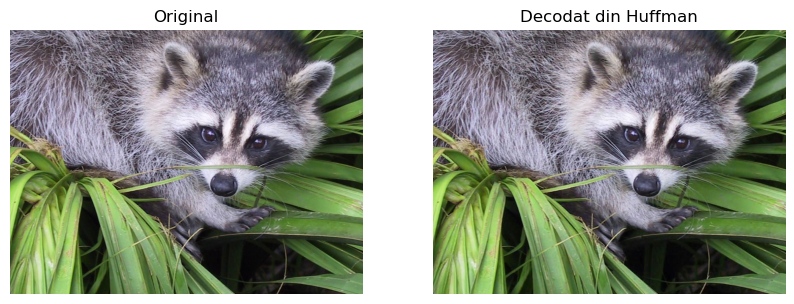

In [16]:
# Logica completa de compresie JPEG (cu tot cu citire valori matrice pe diagonale + Huffman)


def compress_rgb_image_to_jpeg_real(img_rgb, Q_luma, Q_chroma):

    img_ycbcr = image_from_rgb_to_ycbcr(img_rgb)
    h, w, _ = img_ycbcr.shape
    h_pad = h + (8 - h % 8) % 8
    w_pad = w + (8 - w % 8) % 8
    
    all_coeffs = []
    
    #DCT+cuantizare+zigzag pe fiecare canal:
    for c in range(3):
        
        if c == 0: # canalul Y
            Q = Q_luma 
        else: #Cb si Cr
            Q = Q_chroma
            
        canal_curent = np.zeros((h_pad, w_pad))
        canal_curent[:h, :w] = img_ycbcr[..., c]
        
        for i in range(0, h_pad, 8):
            for j in range(0, w_pad, 8):
                block = canal_curent[i:i+8, j:j+8]
                dct_block = dctn(block, type=2, norm='ortho')
                quantized_block = np.round(dct_block / Q).astype(int)

                vector_zigzag = block_to_zigzag(quantized_block)
                all_coeffs.extend(vector_zigzag) # canalele sunt flatten-uite, dar sunt atent la decode sa le reconstruiesc
    
    # codific Huffman vectorul de coeficienti
    bit_stream, tree = huffman_encode(all_coeffs)
    
    
    return {
        'bit_stream': bit_stream,
        'huffman_tree': tree,
        'shape': (h, w, h_pad, w_pad),
        'Q_luma': Q_luma,
        'Q_chroma': Q_chroma
    } # dictionarul ce contine reprezentarea comprimata a imaginii

def load_image_from_compressed(dic):
    
    bit_stream = dic['bit_stream']
    tree = dic['huffman_tree']
    h, w, h_pad, w_pad = dic['shape']
    Q_luma = dic['Q_luma']
    Q_chroma = dic['Q_chroma']
    
    #decodez Huffman si obtin lista de coef cuantizati
    coeffs = huffman_decode(bit_stream, tree)
    
    #reconstruiesc cele 3 canale care fusesera flatten-uite
    img_ycbcr = np.zeros((h_pad, w_pad, 3))
    it = iter(coeffs)
    
    for c in range(3):
        
        if c == 0: # canalul Y
            Q = Q_luma 
        else: #Cb si Cr
            Q = Q_chroma
            
        for i in range(0, h_pad, 8):
            for j in range(0, w_pad, 8):
                
                vector_zigzag_reprezentand_blocul = [next(it) for i in range(64)] #iau de fiecare data urmatoarele 64 de numere din fluxul comprimat, pt ca ele apartin blocului la care lucrez acum
                quantized_block = zigzag_to_block(vector_zigzag_reprezentand_blocul)
                img_ycbcr[i:i+8, j:j+8, c] = idctn(quantized_block * Q, type=2, norm='ortho') # decuantizez si fac idct pt a obtine inapoi blocul
                
    
    img_rgb_unpadded = image_from_ycbcr_to_rgb(img_ycbcr[:h, :w, :])
    return img_rgb_unpadded

#comprimare:
dic_imagine_comprimata = compress_rgb_image_to_jpeg_real(img_color_test, Q_luma, Q_chroma)
# print("pachet comprimat")
# for k in dic_imagine_comprimata.keys():
#     print(k, end = '  ')
#     print(dic_imagine_comprimata[k])
#     print("-------")

#masor cata memorie folosesc
original_bits = img_color_test.size * 8
compressed_bits = len(dic_imagine_comprimata['bit_stream'])

print(f"\n\nDimensiune original (fara niciun fel de compresie): {original_bits/ 8/1024:.2f} KB")
print(f"Dimensiune cu JPEG si Huffman: {compressed_bits/8/ 1024:.2f} KB")
print(f"De cate ori mai eficient dpdv memorie: {original_bits / compressed_bits:.2f} ori")

#incarcare imagine ca RGB, din formatul comprimat
img_incarcata = load_image_from_compressed(dic_imagine_comprimata)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_color_test); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img_incarcata); plt.title("Decodat din Huffman"); plt.axis("off")
plt.show()

# PENTRU VIDEOCLIP:

In [17]:
# pentru videoclip:

# Taskul 4
# Extindeți algoritmul pentru compresie video. Demonstrați pe un clip scurt din care luați fiecare cadru și îl tratați ca pe o imagine.

def compress_video_frames_to_jpeg_real(video_path, output_path, Q_luma, Q_chroma):
    cap = cv2.VideoCapture(video_path) # deschid videoclipul
    
    fps = cap.get(cv2.CAP_PROP_FPS) # ii memorez carcateristicile
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Pentru videoclipul dat: ")
    print(f"- frame w/h: {width}/{height}")
    print(f"- FPS: {fps}")
    print(f"- Total frames: {total_frames}")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # definesc un writer pt video-ul comprimat
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    total_bits_comprimati = 0
    total_bits_originali = 0
    
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) #pt ca videoul e implicit citit in BGR, convertesc la RGB
        
        dic_frame_comprimat = compress_rgb_image_to_jpeg_real(frame_rgb, Q_luma, Q_chroma)
        
        total_bits_comprimati += len(dic_frame_comprimat['bit_stream'])
        total_bits_originali += frame_rgb.size * 8
        
        frame_reconstruit_rgb = load_image_from_compressed(dic_frame_comprimat)
        
        frame_bgr = cv2.cvtColor(frame_reconstruit_rgb, cv2.COLOR_RGB2BGR) # si salvez frame-ul comprimat ca BGR
        out.write(frame_bgr)
        
        frame_idx += 1
        print(f"Procesat frame {frame_idx}")

    cap.release() #eliberare resurse
    out.release()
    
    print("Metrici:")
    print(f"Dimensiune video original: {total_bits_originali/8/1024/1024} MB")
    print(f"Dimensiune video comprimat JPEG: {total_bits_comprimati / 8 / 1024 / 1024} MB")
    print(f"Adica de: {total_bits_originali / total_bits_comprimati} ori mai bine dpdv memorie")

compress_video_frames_to_jpeg_real('budapesta.mp4', 'budapesta_compressed_to_jpegs_real_compression_with_Huffman.mp4', Q_luma, Q_chroma)

Pentru videoclipul dat: 
- frame w/h: 512/480
- FPS: 30.0
- Total frames: 50
Procesat frame 1
Procesat frame 2
Procesat frame 3
Procesat frame 4
Procesat frame 5
Procesat frame 6
Procesat frame 7
Procesat frame 8
Procesat frame 9
Procesat frame 10
Procesat frame 11
Procesat frame 12
Procesat frame 13
Procesat frame 14
Procesat frame 15
Procesat frame 16
Procesat frame 17
Procesat frame 18
Procesat frame 19
Procesat frame 20
Procesat frame 21
Procesat frame 22
Procesat frame 23
Procesat frame 24
Procesat frame 25
Procesat frame 26
Procesat frame 27
Procesat frame 28
Procesat frame 29
Procesat frame 30
Procesat frame 31
Procesat frame 32
Procesat frame 33
Procesat frame 34
Procesat frame 35
Procesat frame 36
Procesat frame 37
Procesat frame 38
Procesat frame 39
Procesat frame 40
Procesat frame 41
Procesat frame 42
Procesat frame 43
Procesat frame 44
Procesat frame 45
Procesat frame 46
Procesat frame 47
Procesat frame 48
Procesat frame 49
Procesat frame 50
Metrici:
Dimensiune video origin